Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont


Carga imagen desde archivo con OpenCV y convierte a RGB

(512, 512, 3)


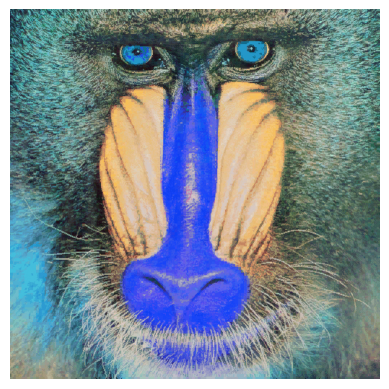

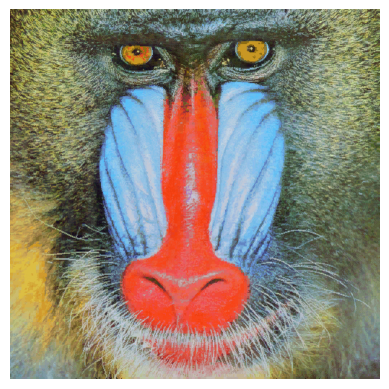

In [2]:
img = cv2.imread('mandril.jpg')

if img is not None:

    print(img.shape)

    plt.figure()

    plt.axis("off")
    plt.imshow(img)
    plt.show()

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure()
    plt.axis("off")
    plt.imshow(img_rgb)
    plt.show()
else:
    print('Imagen no encontrada')


Escribe un texto en una posición de la imagen

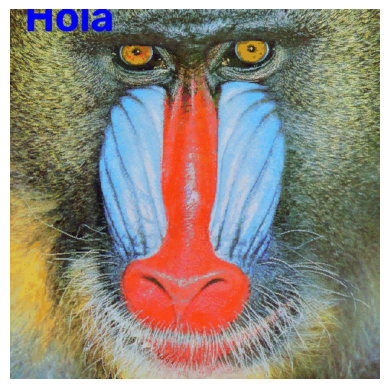

In [3]:
font = cv2.FONT_HERSHEY_SIMPLEX

position=(20,30)
font_scale=2.0
color=(0, 0, 255)
thickness=2

cv2.putText(img_rgb, "Hola", position, font, font_scale, color, thickness)

plt.figure()
plt.axis("off")
plt.imshow(img_rgb)
plt.show()


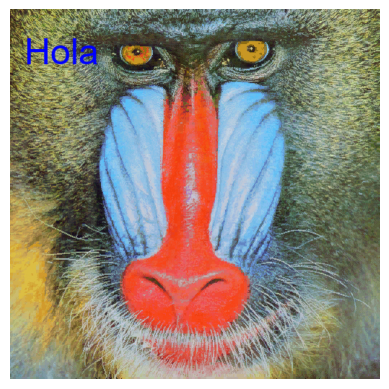

In [4]:
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

pil_image = Image.fromarray(img_rgb)

draw = ImageDraw.Draw(pil_image)

position=(20,30)
font_size=50.0
color=(0, 0, 255)

font = ImageFont.truetype("arial.ttf", font_size)

draw.text(position, "Hola", fill=color, font=font)

final_img_rgb = np.array(pil_image)

plt.figure()
plt.axis("off")
plt.imshow(final_img_rgb)
plt.show()


Convierte la imagen a grises para procesamiento posterior

(512, 512)


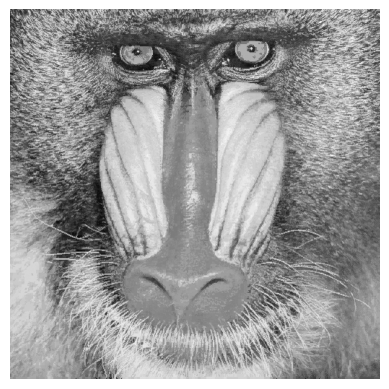

In [5]:
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)

plt.figure()

plt.axis("off")

plt.imshow(gris, cmap='gray')
plt.show()


Canny, detector de contornos multietapa. Descrito en mayor detalle en las sesiones de teoría (tema 4)

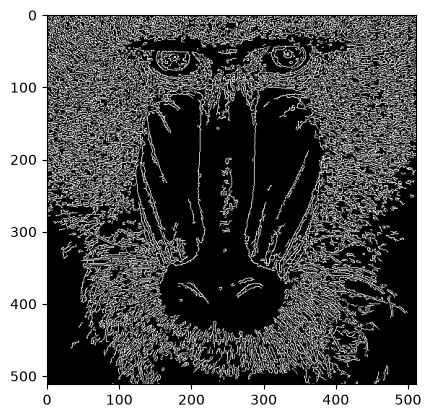

In [6]:
canny = cv2.Canny(gris, 100, 200)

plt.imshow(canny, cmap='gray')
plt.show()


Cuenta el número de píxeles no nulos por columna y visualiza el vector resultante

(0.0, 512.0)

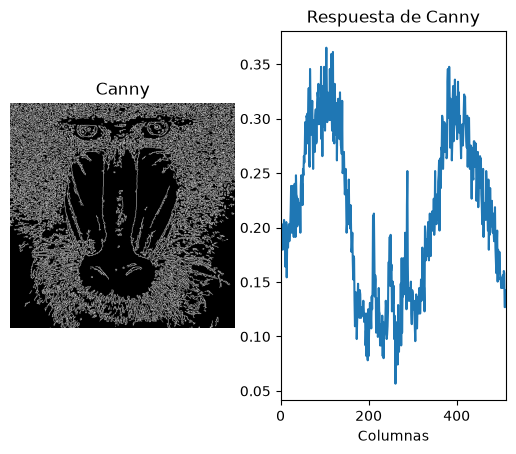

In [7]:
col_counts = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

cols = col_counts[0] / (255 * canny.shape[0])

plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Columnas")
plt.ylabel("% píxeles")
plt.plot(cols)

plt.xlim([0, canny.shape[1]])


TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

Máximo de píxeles blancos por fila: 220
Número de filas con al menos el 90% del máximo: 7
Posiciones de las filas: [6, 12, 15, 20, 21, 88, 100]


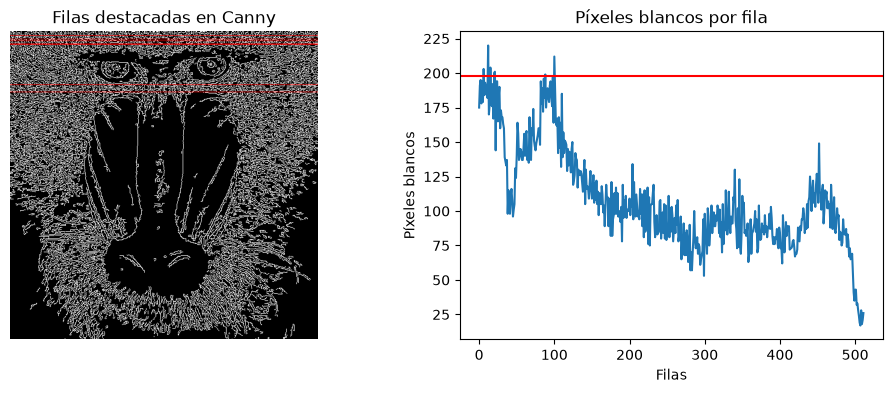

In [8]:
fila_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
filas = (fila_counts[:, 0] / 255).astype(int)
maxfil = int(filas.max())
filas_destacadas = np.where(filas >= 0.90 * maxfil)[0]

print(f"Máximo de píxeles blancos por fila: {maxfil}")
print(f"Número de filas con al menos el 90% del máximo: {len(filas_destacadas)}")
print(f"Posiciones de las filas: {filas_destacadas.tolist()}")

canny_filas = cv2.cvtColor(canny, cv2.COLOR_GRAY2RGB)
for fila in filas_destacadas:
    cv2.line(canny_filas, (0, int(fila)), (canny.shape[1] - 1, int(fila)), (255, 0, 0), 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Filas destacadas en Canny")
plt.imshow(canny_filas)

plt.subplot(1, 2, 2)
plt.title("Píxeles blancos por fila")
plt.xlabel("Filas")
plt.ylabel("Píxeles blancos")
plt.plot(filas)
plt.axhline(0.90 * maxfil, color="red")
plt.show()


Canny es el detector de bordes más destacado antes de los modelos de aprendizaje profundo. Un detector más simple es Sobel (realmente suele usarse como primer paso de Canny).
El operador de Sobel considera que cuando hay un borde, el valor de intensidad de los píxeles cercanos cambia de forma notable, calcular las derivadas proporciona una evidencia de dicho cambio. El operador de Sobel aproxima el cálculo de la derivada aplicando un kernel de tamaño impar basado en el patrón [1 2 1].

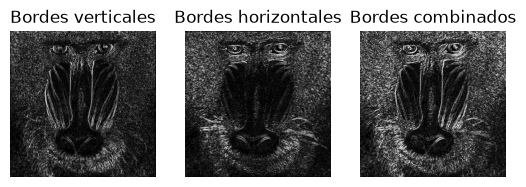

In [9]:
ggris = cv2.GaussianBlur(gris, (3, 3), 0)

sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)

sobel = cv2.add(sobelx, sobely)

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('Bordes verticales')

plt.imshow(cv2.convertScaleAbs(sobelx), cmap='gray')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('Bordes horizontales')

plt.imshow(cv2.convertScaleAbs(sobely), cmap='gray')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Bordes combinados')

plt.imshow(cv2.convertScaleAbs(sobel), cmap='gray')

plt.show()


Observa que visualizar la imagen resultado de Sobel directamente como escala de grises produce un resultado diferente. Ha sido necesario convertir a datos de tipo byte. La siguiente celda muestra dos variantes de conversión, con OpenCV y numpy, evidenciando alguna diferencia, además de los valores antes y tras escalar a 8 bits

Tipo de datos, valor mínimo y máximo en sobel: float64, -594.0, 570.0
Tipo de datos, valor mínimo y máximo en sobel8: uint8, 0, 255
Tipo de datos, valor mínimo y máximo en sobel8np: uint8, 0, 254


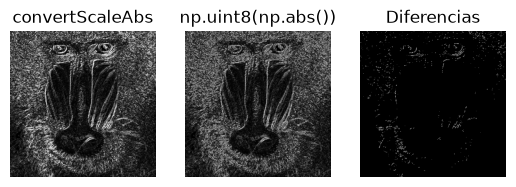

In [10]:
print(f"Tipo de datos, valor mínimo y máximo en sobel: {sobel.dtype}, {np.min(sobel)}, {np.max(sobel)}")

sobel8 = cv2.convertScaleAbs(sobel)

print(f"Tipo de datos, valor mínimo y máximo en sobel8: {sobel8.dtype}, {np.min(sobel8)}, {np.max(sobel8)}")

sobel8np = np.uint8(np.abs(sobel))

print(f"Tipo de datos, valor mínimo y máximo en sobel8np: {sobel8np.dtype}, {np.min(sobel8np)}, {np.max(sobel8np)}")

plt.figure()
plt.subplot(1, 3, 1)
plt.axis("off")
plt.title('convertScaleAbs')
plt.imshow(sobel8, cmap='gray')

plt.subplot(1, 3, 2)
plt.axis("off")
plt.title('np.uint8(np.abs())')
plt.imshow(sobel8np, cmap='gray')

plt.subplot(1, 3, 3)
plt.axis("off")
plt.title('Diferencias')
plt.imshow(cv2.absdiff(sobel8,sobel8np), cmap='gray')

plt.show()


Umbralizado de una imagen

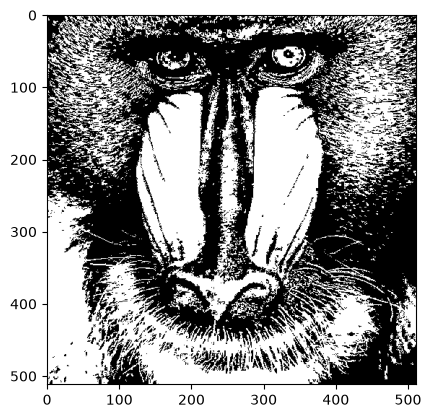

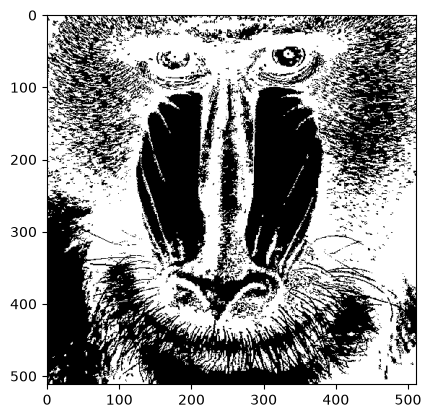

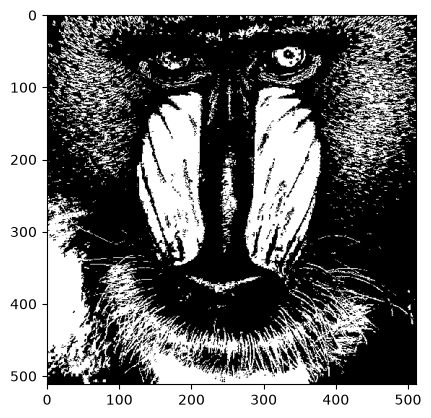

In [11]:
valorUmbral = 130

_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY)

plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

_, imagenUmbralizada = cv2.threshold(gris, valorUmbral, 255, cv2.THRESH_BINARY_INV)

plt.imshow(imagenUmbralizada, cmap='gray')
plt.show()

imagenEnRango = cv2.inRange(gris, 150, 200)

plt.imshow(imagenEnRango, cmap='gray')
plt.show()


El histograma de una imagen aporta información sobre el valor de umbral a elegir para ciertas situaciones

(0.0, 256.0)

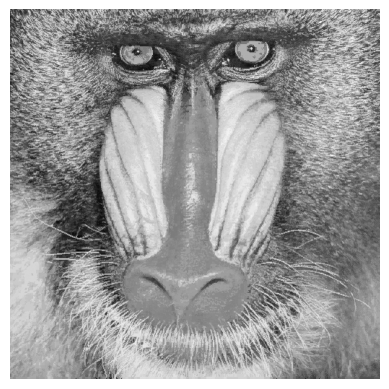

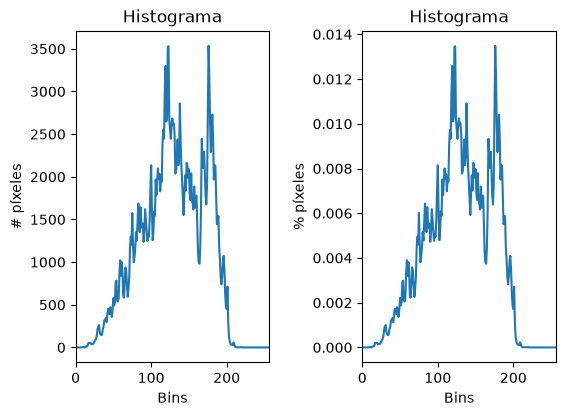

In [12]:
hist = cv2.calcHist([gris], [0], None, [256], [0, 256])

plt.figure()
plt.axis("off")
plt.imshow(gris, cmap='gray')

plt.figure()
plt.subplot(1, 2, 1)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("# píxeles")
plt.plot(hist)
plt.xlim([0, 256])

hist /= hist.sum()

plt.subplot(1, 2, 2)
plt.title("Histograma")
plt.xlabel("Bins")
plt.ylabel("% píxeles")
plt.tight_layout(pad=3.0)
plt.plot(hist)
plt.xlim([0, 256])


TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

Sobel umbralizado con umbral 60
Máximo por filas Sobel: 328
Filas Sobel >= 90%: [1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 15, 18, 19, 20, 24, 52, 80, 82, 83, 84, 85, 87, 88, 93, 96, 99, 100]
Máximo por columnas Sobel: 314
Columnas Sobel >= 90%: [90, 99, 100, 103, 104, 105, 106, 107, 112, 119, 123, 125, 126, 127, 128, 132]
Máximo por filas Canny: 220
Filas Canny >= 90%: [6, 12, 15, 20, 21, 88, 100]
Máximo por columnas Canny: 187
Columnas Canny >= 90%: [67, 86, 92, 96, 99, 100, 103, 104, 105, 112, 115, 119, 123, 379, 380, 383, 392, 396, 403]


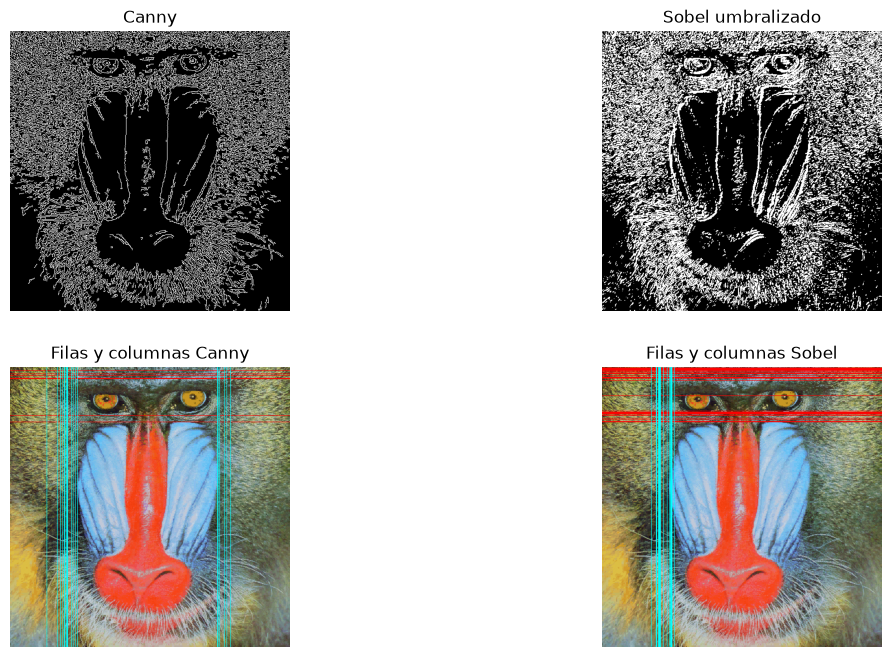

In [13]:
valor_umbral_sobel = 60
_, sobel_umbral = cv2.threshold(sobel8, valor_umbral_sobel, 255, cv2.THRESH_BINARY)

filas_sobel = (cv2.reduce(sobel_umbral, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0] / 255).astype(int)
columnas_sobel = (cv2.reduce(sobel_umbral, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] / 255).astype(int)

maxfil_sobel = int(filas_sobel.max())
maxcol_sobel = int(columnas_sobel.max())
filas_sobel_destacadas = np.where(filas_sobel >= 0.90 * maxfil_sobel)[0]
columnas_sobel_destacadas = np.where(columnas_sobel >= 0.90 * maxcol_sobel)[0]

filas_canny = (cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[:, 0] / 255).astype(int)
columnas_canny = (cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)[0] / 255).astype(int)
maxfil_canny = int(filas_canny.max())
maxcol_canny = int(columnas_canny.max())
filas_canny_destacadas = np.where(filas_canny >= 0.90 * maxfil_canny)[0]
columnas_canny_destacadas = np.where(columnas_canny >= 0.90 * maxcol_canny)[0]

mandril_sobel = img_rgb.copy()
mandril_canny = img_rgb.copy()

for fila in filas_sobel_destacadas:
    cv2.line(mandril_sobel, (0, int(fila)), (mandril_sobel.shape[1] - 1, int(fila)), (255, 0, 0), 1)

for columna in columnas_sobel_destacadas:
    cv2.line(mandril_sobel, (int(columna), 0), (int(columna), mandril_sobel.shape[0] - 1), (0, 255, 255), 1)

for fila in filas_canny_destacadas:
    cv2.line(mandril_canny, (0, int(fila)), (mandril_canny.shape[1] - 1, int(fila)), (255, 0, 0), 1)

for columna in columnas_canny_destacadas:
    cv2.line(mandril_canny, (int(columna), 0), (int(columna), mandril_canny.shape[0] - 1), (0, 255, 255), 1)

print(f"Sobel umbralizado con umbral {valor_umbral_sobel}")
print(f"Máximo por filas Sobel: {maxfil_sobel}")
print(f"Filas Sobel >= 90%: {filas_sobel_destacadas.tolist()}")
print(f"Máximo por columnas Sobel: {maxcol_sobel}")
print(f"Columnas Sobel >= 90%: {columnas_sobel_destacadas.tolist()}")
print(f"Máximo por filas Canny: {maxfil_canny}")
print(f"Filas Canny >= 90%: {filas_canny_destacadas.tolist()}")
print(f"Máximo por columnas Canny: {maxcol_canny}")
print(f"Columnas Canny >= 90%: {columnas_canny_destacadas.tolist()}")

plt.figure(figsize=(14, 8))
plt.subplot(2, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap="gray")

plt.subplot(2, 2, 2)
plt.axis("off")
plt.title("Sobel umbralizado")
plt.imshow(sobel_umbral, cmap="gray")

plt.subplot(2, 2, 3)
plt.axis("off")
plt.title("Filas y columnas Canny")
plt.imshow(mandril_canny)

plt.subplot(2, 2, 4)
plt.axis("off")
plt.title("Filas y columnas Sobel")
plt.imshow(mandril_sobel)
plt.show()


Comparación: Canny produce bordes más finos y seleccionados porque incluye suavizado, gradiente, supresión de no máximos e histéresis. Sobel umbralizado marca más zonas de cambio de intensidad, por eso suele generar regiones más gruesas y más ruido. En esta imagen, Canny es más limpio para localizar contornos, mientras que Sobel ofrece una respuesta más amplia de textura y cambios locales.

Diferencia de imágenes

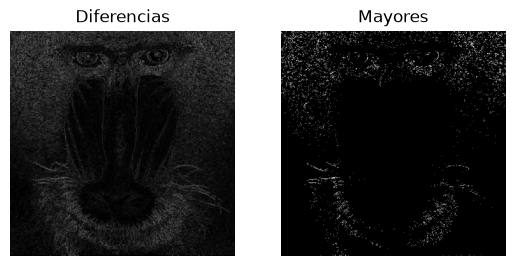

In [14]:
dif = cv2.absdiff(gris, ggris)

plt.figure()
plt.subplot(1, 2, 1)
plt.title("Diferencias")
plt.axis("off")
plt.imshow(dif, cmap='gray')

res, imgdif = cv2.threshold(dif, 30, 255, cv2.THRESH_BINARY)

plt.subplot(1, 2, 2)
plt.title("Mayores")
plt.axis("off")
plt.imshow(imgdif, cmap='gray')
plt.show()


Webcam y sustracción de fotogramas

In [15]:
vid = cv2.VideoCapture(0)

disponible = 0
while(True):

    ret, frame = vid.read()

    if ret:
        if disponible > 0:
            dif = cv2.absdiff(frame, pframe)

            cv2.imshow('Diferencia', dif)
        else:
            disponible = 1

        pframe = frame.copy()

    if cv2.waitKey(20) == 27:
        break

vid.release()

cv2.destroyAllWindows()


KeyboardInterrupt: 

Webcam y sustracción de modelo del fondo

In [ ]:
vid = cv2.VideoCapture(0)

eliminadorFondo = cv2.createBackgroundSubtractorMOG2(history=100, varThreshold=50, detectShadows=True)

while(True):

    ret, frame = vid.read()

    if ret:

        framem=cv2.flip(frame, 1)

        objetos = eliminadorFondo.apply(framem)

        background = eliminadorFondo.getBackgroundImage()

        cv2.imshow('Fotograma', objetos)

        cv2.imshow('Fondo', background)

    if cv2.waitKey(20) == 27:
        break

vid.release()

cv2.destroyAllWindows()


TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

Propuesta de demostrador: una cortina de privacidad inspirada en *My little piece of privacy*. La webcam se muestra en espejo, se detectan las zonas en movimiento con sustracción de fondo y esas regiones se sustituyen por un mosaico pixelado. Así se mantiene visible la escena, pero se oculta la parte activa de la persona que aparece ante la cámara.

In [ ]:
# Demostrador: Cortina de privacidad inspirada en *My little piece of privacy*
# Inspiracion: la instalacion de Niklas Roy donde una maquina sigue al visitante
# con una cortina para ocultarle. Aqui reinterpretamos la idea digitalmente:
# las zonas en movimiento (persona) se pixelan para proteger su privacidad.

vid = cv2.VideoCapture(0, cv2.CAP_DSHOW)  # CAP_DSHOW evita bloqueos en Windows

# MOG2: substractor de fondo adaptativo
eliminador_fondo = cv2.createBackgroundSubtractorMOG2(
    history=100, varThreshold=50, detectShadows=False
)
kernel = np.ones((5, 5), np.uint8)

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # Efecto espejo (mas intuitivo para el usuario)
    frame = cv2.flip(frame, 1)

    # 1) Obtener mascara de movimiento
    mascara = eliminador_fondo.apply(frame)
    # Eliminar sombras y ruido puntual
    _, mascara = cv2.threshold(mascara, 200, 255, cv2.THRESH_BINARY)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, kernel)
    mascara = cv2.dilate(mascara, kernel, iterations=2)

    # 2) Crear efecto mosaico (pixelado) sobre todo el frame
    h, w = frame.shape[:2]
    mini = cv2.resize(frame, (max(1, w // 16), max(1, h // 16)),
                       interpolation=cv2.INTER_LINEAR)
    mosaico = cv2.resize(mini, (w, h), interpolation=cv2.INTER_NEAREST)

    # 3) Aplicar mosaico solo donde hay movimiento
    resultado = frame.copy()
    resultado[mascara > 0] = mosaico[mascara > 0]

    # 4) Dibujar contornos de las zonas en movimiento (solo los significativos)
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL,
                                     cv2.CHAIN_APPROX_SIMPLE)
    contornos = [c for c in contornos if cv2.contourArea(c) > 800]
    cv2.drawContours(resultado, contornos, -1, (0, 255, 255), 2)

    cv2.imshow('Cortina de privacidad', resultado)
    cv2.imshow('Movimiento detectado', mascara)

    if cv2.waitKey(20) & 0xFF == 27:  # ESC para salir
        break

vid.release()
cv2.destroyAllWindows()


## Conclusiones del demostrador

El demostrador implementado esta inspirado en la instalacion **My little piece of privacy** de Niklas Roy, en la que una maquina motorizada mueve una cortina para seguir al visitante y ocultarle de una camara de videovigilancia.

En nuestra reinterpretacion digital:

- Se captura video en tiempo real desde la webcam (modo espejo).
- Se aplica sustraccion de fondo con **MOG2** para detectar zonas en movimiento.
- Las zonas donde hay movimiento (la persona) se sustituyen por un **mosaico pixelado** (bloques de 16x16 px), lo que oculta los detalles de la persona sin borrarla completamente.
- Se dibujan los contornos de las zonas en movimiento en cian para visualizar que esta detectando el sistema.
- El fondo estatico permanece visible con total nitidez.

El efecto es el inverso al de la instalacion original: aqui se protege la privacidad de **lo que se mueve** (la persona), en lugar de ocultarla de la camara mediante una cortina fisica. Esta reinterpretacion muestra como el procesamiento de imagen puede emplearse como herramienta artistica e interactiva.

Pulsar **ESC** para salir del bucle de captura.
